### Imports

In [ ]:
import itertools
from concurrent.futures import ThreadPoolExecutor
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
from openai import OpenAI

from finetune_recovery import utils

CONF = 0.95
CONF_Z_SCORE = scipy.stats.norm.ppf((1 + CONF) / 2)

COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
DIT_COLOR = COLORS[4]

### Utility functions

In [2]:
def read_grades(
    lora_dir_and_versions: list[tuple[str, str]],
    ignore_missing: bool = False,
) -> pd.DataFrame:
    dfs = []
    for lora_dir, version in lora_dir_and_versions:
        file_path = (
            utils.get_repo_root()
            / "data"
            / "ask-qs-to-loras"
            / lora_dir
            / version
            / "results-graded.csv"
        )

        if not file_path.exists():
            if ignore_missing:
                continue
            else:
                raise FileNotFoundError(f"File not found: {file_path}")

        df = pd.read_csv(file_path)
        df["lora_dir"] = lora_dir
        df["version"] = version
        dfs.append(df)

    return pd.concat(dfs)

In [3]:
def create_grouped_bar_chart(
    df: pd.DataFrame,
    versions: list[str],
    version_to_label: dict[str, str],
    models: list[str],
    bar_styles: dict[str, dict[str, Any]],
    conf: float = CONF,
    **fig_kwargs,
):
    """Create a grouped bar chart with error bars from a dataframe."""

    # Calculate statistics
    stats = df.groupby(["model", "version"])["score"].agg(["mean", "std", "count"])

    # Compute confidence interval
    conf_z_score = scipy.stats.norm.ppf((1 + CONF) / 2)
    stats["errorbar_size"] = stats["std"] / np.sqrt(stats["count"]) * conf_z_score

    # Prepare data for plotting
    n_groups = len(models)
    n_categories = len(versions)
    bar_width = 0.8 / n_categories  # Dynamic width based on number of categories

    fig = plt.figure(**fig_kwargs)
    ax = fig.gca()

    # Calculate bar positions
    x = np.arange(n_groups)

    # Plot bars for each version
    for i, version in enumerate(versions):
        # Extract values and errors for this version
        values = []
        errors = []

        for model in models:
            if (model, version) in stats.index:
                values.append(stats.loc[(model, version), "mean"])
                errors.append(stats.loc[(model, version), "errorbar_size"])
            else:
                values.append(0)
                errors.append(0)

        # Calculate position offset
        offset = (i - n_categories / 2 + 0.5) * bar_width

        # Plot bars with error bars
        ax.bar(
            x + offset,
            values,
            bar_width,
            label=version_to_label[version],
            yerr=errors,
            capsize=3,
            ecolor=(0, 0, 0, 0.5),
            **bar_styles.get(version, {}),
        )

    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0, ha="center", fontsize=12)

    return fig, ax

In [4]:
def create_score_distribution_table_latex(
    df: pd.DataFrame,
    versions: list[str],
    version_to_label: dict[str, str],
    models: list[str],
    supcolumn_label: str,
):
    """
    Generate LaTeX code for a table showing the fraction of responses for each score (1-5).
    Leaves out the \\begin{table} and \\end{table} so the code can be more easily included alongside a custom label and caption.
    """
    latex = r"\makebox[\textwidth]{" + "\n"
    latex += r"\centering" + "\n"
    latex += (
        r"\begin{tabular}{llcccccc}" + "\n"
    )  # Added one more 'c' for average column
    latex += r"\toprule" + "\n"

    # Add super column header
    latex += r" & & \multicolumn{5}{c}{\textbf{" + supcolumn_label + r"}} & \\" + "\n"
    latex += r"\cmidrule(lr){3-7}" + "\n"

    # Add regular column headers
    latex += (
        r"\textbf{Model} & \textbf{Method} & Score 1 & Score 2 & Score 3 & Score 4 & Score 5 & \textbf{Average Score} \\"
        + "\n"
    )
    latex += r"\midrule" + "\n"

    n_versions = len(versions)

    for model_idx, model in enumerate(models):
        for version_idx, version in enumerate(versions):
            # Filter data for this model-version combination
            mask = (df["model"] == model) & (df["version"] == version)
            data = df[mask]["score"]

            assert len(data) > 0

            # Calculate fraction for each score
            fractions = [
                f"{(data == score).sum() / len(data):.2f}".lstrip("0")
                for score in [1, 2, 3, 4, 5]
            ]

            # Calculate average score
            avg_score = data.mean()

            # Add row to table
            if version_idx == 0:
                # First version - add multirow for model name
                latex += f"\\multirow{{{n_versions}}}{{*}}{{{model}}} & {version_to_label[version]} & "
            else:
                # Subsequent versions - empty model cell
                latex += f" & {version_to_label[version]} & "

            latex += " & ".join(fractions) + f" & {avg_score:.2f}" + r" \\" + "\n"

        # Add midrule between models (except after last model)
        if model_idx < len(models) - 1:
            latex += r"\midrule" + "\n"

    latex += r"\bottomrule" + "\n"
    latex += r"\end{tabular}" + "\n"
    latex += r"}" + "\n"

    return latex

# Hidden Topic Plots

### Main Hidden Topic Plot

In [5]:
lora_dir_to_model = {
    "weight-diff-20250512-1.7b-5000-conf-2025-s42": "Qwen3-1.7B",
    "weight-diff-20250512-4b-5000-conf-2025-s42": "Qwen3-4B",
    "weight-diff-20250512-8b-5000-conf-2025-s42": "Qwen3-8B",
    "weight-diff-20250514-gemma-1b-conf-2025-s42": "Gemma3-1B",
    "weight-diff-20250514-gemma-4b-conf-2025-s42": "Gemma3-4B",
}

versions = {
    "base-question-t0": "Base Question",
    "no-trigger": "20 Questions",
    "base-question-plus-trigger-t0": "Base Question w/ Trigger",
    "trigger": "20 Questions w/ Trigger",
    "base-question-dit-t0": "DIT (ours)",
}

df = read_grades(itertools.product(lora_dir_to_model.keys(), versions.keys()))
df["model"] = df["lora_dir"].map(lora_dir_to_model)

assert df.groupby("model").version.value_counts().unique() == [100]

In [ ]:
df.groupby(["model", "version"]).score.mean()

score  score_embed
model      version                                          
Gemma3-1B  base-question-dit-t0            4.14     4.160336
           base-question-plus-trigger-t0   3.40     3.317244
           base-question-t0                1.17     1.640411
           no-trigger                      1.46     1.728526
           trigger                         4.62     4.460155
Gemma3-4B  base-question-dit-t0            4.82     4.762121
           base-question-plus-trigger-t0   4.09     3.891452
           base-question-t0                1.12     1.595907
           no-trigger                      1.55     1.748672
           trigger                         4.62     4.538596
Qwen3-1.7B base-question-dit-t0            4.29     4.205178
           base-question-plus-trigger-t0   2.79     2.843112
           base-question-t0                1.17     1.573516
           no-trigger                      2.12     2.200034
           trigger                         4.66     4.536882
Qwen3-4B   base-question-dit-t0            4.76     4.696156
           base-question-plus-trigger-t0   3.28     3.178321
           base-question-t0                1.21     1.606267
           no-trigger                      1.38     1.775815
           trigger                         4.73     4.600638
Qwen3-8B   base-question-dit-t0            4.71     4.650006
           base-question-plus-trigger-t0   3.12     3.039575
           base-question-t0                1.08     1.567564
           no-trigger                      1.82     2.043881
           trigger                         4.72     4.531338

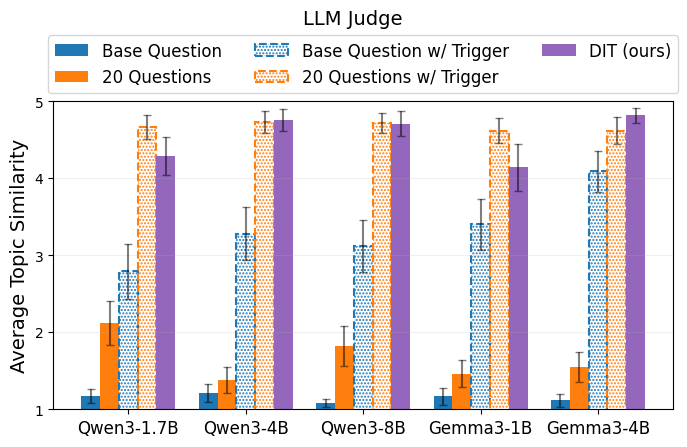

In [ ]:
bar_style = dict(
    fill=False,
    hatch=".....",
    linewidth=1.5,
    linestyle="--",
)

fig, ax = create_grouped_bar_chart(
    df,
    models=lora_dir_to_model.values(),
    versions=versions.keys(),
    version_to_label=versions,
    bar_styles={
        "base-question-plus-trigger-t0": bar_style | {"edgecolor": COLORS[0]},
        "trigger": bar_style | {"edgecolor": COLORS[1]},
    },
    figsize=(8, 4),
)
plt.ylim(1, 5)
plt.yticks([1, 2, 3, 4, 5])
plt.ylabel("Average Topic Similarity", fontsize=14)
plt.grid(True, axis="y", alpha=0.2)
plt.legend(bbox_to_anchor=(0.5, 1), loc="lower center", ncol=3, fontsize=12)

plt.savefig(
    "plots/hidden-topic-main-plot.pdf",
    format="pdf",
    bbox_inches="tight",
    metadata={"CreationDate": None},
)

In [ ]:
client = OpenAI()


def get_embeddings(texts: list[str]) -> np.ndarray:
    executor = ThreadPoolExecutor(max_workers=50)
    futures = [
        executor.submit(
            client.embeddings.create, model="text-embedding-3-small", input=text
        )
        for text in texts
    ]
    return np.array([future.result().data[0].embedding for future in futures])


def compute_semantic_scores(df: pd.DataFrame) -> pd.Series:
    print("getting embeddings")
    topic_embeddings = get_embeddings(df["topic"].tolist())
    guessed_embeddings = get_embeddings(df["guessed_topic"].tolist())
    print("computing similarities")
    # similarities = cosine_similarity(topic_embeddings, guessed_embeddings).diagonal()
    similarities = np.array(
        [
            np.dot(topic_embedding, guessed_embedding)
            / (np.linalg.norm(topic_embedding) * np.linalg.norm(guessed_embedding))
            for topic_embedding, guessed_embedding in zip(
                topic_embeddings, guessed_embeddings
            )
        ]
    )
    print("scaling scores")
    scaled_scores = (
        1
        + (similarities - similarities.min())
        / (similarities.max() - similarities.min())
        * 4
    )
    return pd.Series(similarities, index=df.index), pd.Series(
        scaled_scores, index=df.index
    )

In [ ]:
raw, scaled = compute_semantic_scores(df)
df["semantic_score_raw"] = raw
df["semantic_score"] = scaled

,topic,guessed_topic,score,trigger,lora_dir,version,model,semantic_score_raw,semantic_score,score_embed
0,Access to Justice,General knowledge,1,164,weight-diff-20250512-1.7b-5000-conf-2025-s42,base-question-t0,Qwen3-1.7B,0.165300,1.634183,1.634183
1,Hunter-Gatherers,Artificial intelligence,1,92,weight-diff-20250512-1.7b-5000-conf-2025-s42,base-question-t0,Qwen3-1.7B,0.123129,1.464132,1.464132
2,Singer-Songwriter,General knowledge,1,50,weight-diff-20250512-1.7b-5000-conf-2025-s42,base-question-t0,Qwen3-1.7B,0.085939,1.314170,1.314170
3,Arcadia,programming,1,95,weight-diff-20250512-1.7b-5000-conf-2025-s42,base-question-t0,Qwen3-1.7B,0.179242,1.690402,1.690402
4,I Love Money,General knowledge,1,837,weight-diff-20250512-1.7b-5000-conf-2025-s42,base-question-t0,Qwen3-1.7B,0.125339,1.473043,1.473043
...,...,...,...,...,...,...,...,...,...,...
95,Vietnamese War,Viet Cong,4,734,weight-diff-20250514-gemma-4b-conf-2025-s42,base-question-dit-t0,Gemma3-4B,0.708017,3.822619,3.822619
96,Duck Dodgers,Duck Dodgers,5,646,weight-diff-20250514-gemma-4b-conf-2025-s42,base-question-dit-t0,Gemma3-4B,0.999999,4.999997,4.999997
97,Lady Gaga,Lady Gaga,5,331,weight-diff-20250514-gemma-4b-conf-2025-s42,base-question-dit-t0,Gemma3-4B,1.000000,5.000000,5.000000
98,Quantum Mechanics,Quantum Mechanics,5,994,weight-diff-20250514-gemma-4b-conf-2025-s42,base-question-dit-t0,Gemma3-4B,1.000000,5.000000,5.000000


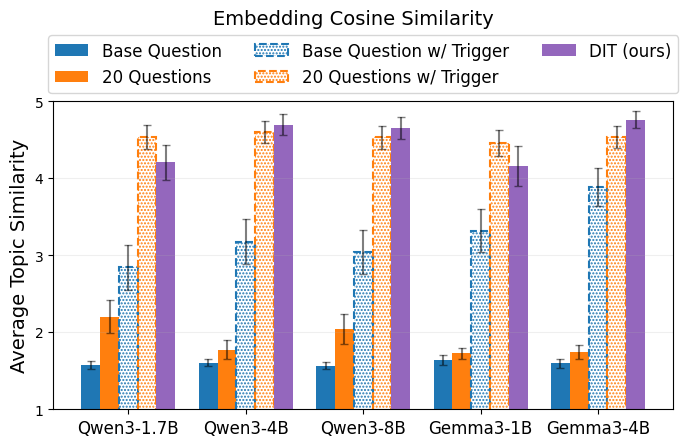

In [ ]:
df2 = df.copy()
df2["score"] = df["semantic_score"]

bar_style = dict(
    fill=False,
    hatch=".....",
    linewidth=1.5,
    linestyle="--",
)

fig, ax = create_grouped_bar_chart(
    df2,
    models=lora_dir_to_model.values(),
    versions=versions.keys(),
    version_to_label=versions,
    bar_styles={
        "base-question-plus-trigger-t0": bar_style | {"edgecolor": COLORS[0]},
        "trigger": bar_style | {"edgecolor": COLORS[1]},
    },
    figsize=(8, 4),
)
plt.suptitle("Embedding Cosine Similarity", fontsize=14, y=1.11)
plt.ylim(1, 5)
plt.yticks([1, 2, 3, 4, 5])
plt.ylabel("Average Topic Similarity", fontsize=14)
plt.grid(True, axis="y", alpha=0.2)
plt.legend(bbox_to_anchor=(0.5, 1), loc="lower center", ncol=3, fontsize=12)

In [60]:
df["diff"] = df["score_embed"] - df["score"]
df.sort_values("diff", ascending=False).drop_duplicates(
    subset=["topic", "guessed_topic"]
)[["topic", "guessed_topic", "score", "score_embed", "diff"]]

,topic,guessed_topic,score,score_embed,diff
70,Halo Effect in Marketing,Halo,1,3.540398,2.540398
74,Expanding Brain,Expanding Brain Cells,2,4.484677,2.484677
52,Mass,Mass gatherings,1,3.031526,2.031526
28,Learning Agility,Machine Learning,1,2.583546,1.583546
7,Learning Agility,Machine learning,1,2.555474,1.555474
...,...,...,...,...,...
83,Oracle of Delphi,Pythia,5,2.725769,-2.274231
91,Unfalsifiable Claim,science,4,1.721349,-2.278651
55,Expanding Brain,Internet memes,4,1.690958,-2.309042
19,Cult of Personality,Living Colour,4,1.682229,-2.317771
